In [2]:
import numpy as np
from pathlib import Path

PROCESSED_SOLANUM = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed\solanum")
HEALTHY_DIR = PROCESSED_SOLANUM / "healthy"
STRESSED_DIR = PROCESSED_SOLANUM / "stressed"

def verify_dataset():
    print("=" * 50)
    print("🔍 VERIFYING PROCESSED SOLANUM DATASET")
    print("=" * 50)
    
    if not PROCESSED_SOLANUM.exists():
        print(f"❌ Error: Directory '{PROCESSED_SOLANUM}' does not exist. Did you run data_loader.py?")
        return

    healthy_files = list(HEALTHY_DIR.glob("*.npy"))
    stressed_files = list(STRESSED_DIR.glob("*.npy"))
    
    print(f"Healthy Windows Count:   {len(healthy_files)}")
    print(f"Stressed Windows Count:  {len(stressed_files)}")
    print(f"Total Training Samples:  {len(healthy_files) + len(stressed_files)}")
    
    # Check shape consistency of a sample file
    if healthy_files:
        sample_path = healthy_files[0]
        sample_array = np.load(sample_path)
        print(f"\nSample File Shape:       {sample_array.shape} (Expected: (10000,))")
        print(f"Sample Data Type:        {sample_array.dtype}")
        print(f"Sample Min / Max Val:    {sample_array.min():.2f} / {sample_array.max():.2f}")
    
    print("=" * 50)

if __name__ == "__main__":
    verify_dataset()

🔍 VERIFYING PROCESSED SOLANUM DATASET
Healthy Windows Count:   23
Stressed Windows Count:  18
Total Training Samples:  41

Sample File Shape:       (65000,) (Expected: (10000,))
Sample Data Type:        float64
Sample Min / Max Val:    -4.21 / 4.55


Grabbing random samples from each stress class...

Success! Open the image saved here: g:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\src\debug_waveforms.png


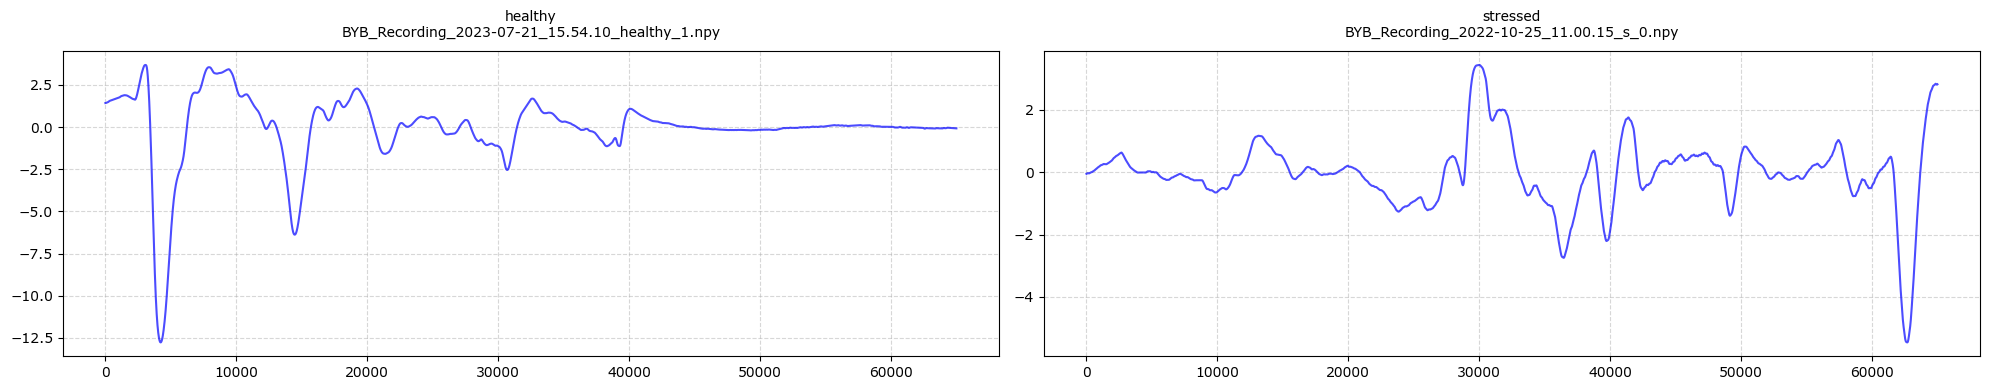

In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
NPY_FOLDERS_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed\solanum")

def visualize_random_samples():
    print("Grabbing random samples from each stress class...")
    
    if not NPY_FOLDERS_DIR.exists():
        print(f"Error: Could not find {NPY_FOLDERS_DIR}")
        return
        
    folders = sorted([d for d in NPY_FOLDERS_DIR.iterdir() if d.is_dir()])
    
    if not folders:
        print("No folders found!")
        return

    # Create a wide plot for the 5 classes
    fig, axes = plt.subplots(1, len(folders), figsize=(20, 4))
    
    for idx, folder in enumerate(folders):
        files = list(folder.glob("*.npy"))
        if not files:
            continue
            
        random_file = random.choice(files)
        
        # Load the raw 2-second math array we generated
        signal = np.load(random_file)
        
        # Plot the soundwave
        axes[idx].plot(signal, color='blue', alpha=0.7)
        axes[idx].set_title(f"{folder.name}\n{random_file.name}", fontsize=10, pad=10)
        
        # Lock the Y-axis so we can see if the volume is clipping or silent
        # axes[idx].set_ylim([-30000, 30000]) 
        axes[idx].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    save_path = "debug_waveforms.png"
    plt.savefig(save_path, dpi=150)
    print(f"\nSuccess! Open the image saved here: {os.path.abspath(save_path)}")
    plt.show()

if __name__ == "__main__":
    visualize_random_samples()

In [7]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED_SOLANUM = Path("../data/processed/solanum")
BATCH_SIZE = 8          # Lowered for a 41-sample dataset
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 0.0003 
TARGET_LENGTH = 65000   # Updated to hold the full 6.5s wave
SAMPLE_RATE = 10000

# --- 1. DATASET & MEL-SPECTROGRAM + SPECAUGMENT ---
class PlantPulseMelDataset(Dataset):
    def __init__(self, file_paths, labels, transform=False):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
        # High-Res MelSpectrogram
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=128,
            n_mels=128
        )
        # Convert power to decibels (log scale) for better contrast
        self.amplitude_to_db = T.AmplitudeToDB()
        
        # SpecAugment for robust 2D training
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=15)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        
        # Convert to Mel-Spectrogram Image
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        
        # Add channel dimension -> Shape: (1, n_mels, time_frames)
        mel_db = mel_db.unsqueeze(0)
        
        if self.transform:
            mel_db = self.freq_mask(mel_db)
            mel_db = self.time_mask(mel_db)
            
        label = np.array([self.labels[idx]], dtype=np.float32)
        return mel_db, torch.tensor(label)

# --- 2. ARCHITECTURE: RESNET18 (TRANSFER LEARNING) ---
class PlantPulseResNet(nn.Module):
    def __init__(self):
        super(PlantPulseResNet, self).__init__()
        # Load ImageNet pretrained weights to prevent overfitting on small datasets
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Adapt first layer for 1-channel grayscale Mel-spectrograms
        # Preserving original pretrained weights by averaging across RGB channels
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5), # Increased dropout to prevent memorization
            nn.Linear(num_ftrs, 1)
        )

    def forward(self, x):
        return self.resnet(x)

# --- 3. TRAINING PIPELINE ---
def main():
    print("Initializing High-Res Pretrained ResNet Pipeline...")
    
    healthy_dir = PROCESSED_SOLANUM / "healthy"
    stressed_dir = PROCESSED_SOLANUM / "stressed"
    
    if not healthy_dir.exists() or not stressed_dir.exists():
        print(f"Error: Directories not found at {PROCESSED_SOLANUM}.")
        return
        
    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))
    
    all_files = healthy_files + stressed_files
    all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)
    
    print(f"Total Data: {len(all_files)} samples ({len(healthy_files)} Healthy | {len(stressed_files)} Stressed)")

    # Stratified Split
    X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    
    print(f"Split: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

    train_dataset = PlantPulseMelDataset(X_train, y_train, transform=True)
    val_dataset = PlantPulseMelDataset(X_val, y_val, transform=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    
    model = PlantPulseResNet().to(device)
    
    # Class Weight for Imbalance
    num_neg = len([y for y in y_train if y == 0])
    num_pos = len([y for y in y_train if y == 1])
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Optimizer with L2 Regularization (weight_decay)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # Cosine Annealing Learning Rate Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs) >= 0.5
            train_correct += (preds == labels).sum().item()
            
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Step the learning rate scheduler after each epoch
        scheduler.step()

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                preds = torch.sigmoid(outputs) >= 0.5
                val_correct += (preds == labels).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        # Get current learning rate to print it
        current_lr = scheduler.get_last_lr()[0]
        
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic (Monitoring Val Loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    os.makedirs("../models", exist_ok=True)
    save_path = "../models/solanum_resnet18_mel.pth"
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), save_path)
    print(f"Best model saved to: {save_path}")

if __name__ == "__main__":
    main()

Initializing High-Res Pretrained ResNet Pipeline...
Total Data: 41 samples (23 Healthy | 18 Stressed)
Split: Train=28 | Val=6 | Test=7
Training on: cuda
Epoch 001/100 | LR: 0.000300 | Train Loss: 0.5905 Acc: 0.6429 | Val Loss: 0.8321 Acc: 0.3333
Epoch 002/100 | LR: 0.000300 | Train Loss: 0.4690 Acc: 0.7857 | Val Loss: 0.7872 Acc: 0.5000
Epoch 003/100 | LR: 0.000299 | Train Loss: 0.5820 Acc: 0.8214 | Val Loss: 0.9573 Acc: 0.8333
Epoch 004/100 | LR: 0.000299 | Train Loss: 0.2938 Acc: 0.8929 | Val Loss: 1.0268 Acc: 0.8333
Epoch 005/100 | LR: 0.000298 | Train Loss: 0.4217 Acc: 0.8929 | Val Loss: 0.8997 Acc: 0.8333
Epoch 006/100 | LR: 0.000297 | Train Loss: 0.2102 Acc: 0.9643 | Val Loss: 0.6448 Acc: 0.8333
Epoch 007/100 | LR: 0.000296 | Train Loss: 0.3542 Acc: 0.8929 | Val Loss: 0.7248 Acc: 0.8333
Epoch 008/100 | LR: 0.000295 | Train Loss: 0.1823 Acc: 0.9286 | Val Loss: 1.1954 Acc: 0.8333
Epoch 009/100 | LR: 0.000294 | Train Loss: 0.1564 Acc: 0.9643 | Val Loss: 1.0162 Acc: 0.8333
Epoch 010/

In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED_SOLANUM = Path("../data/processed/solanum")
BATCH_SIZE = 8
TARGET_LENGTH = 65000   # Updated to hold the full 6.5s wave
SAMPLE_RATE = 10000
MODEL_PATH = "../models/solanum_resnet18_mel.pth"

# --- DATASET (Same as training, no augmentations) ---
class PlantPulseTestDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=128,
            n_mels=128
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        mel_db = mel_db.unsqueeze(0)
        
        label = np.array([self.labels[idx]], dtype=np.float32)
        return mel_db, torch.tensor(label)

# --- MODEL ARCHITECTURE ---
class PlantPulseResNet(nn.Module):
    def __init__(self):
        super(PlantPulseResNet, self).__init__()
        self.resnet = models.resnet18(weights=None)
        
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1)
        )

    def forward(self, x):
        return self.resnet(x)

def main():
    print("Loading test data...")
    
    healthy_dir = PROCESSED_SOLANUM / "healthy"
    stressed_dir = PROCESSED_SOLANUM / "stressed"
    
    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))
    
    all_files = healthy_files + stressed_files
    all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)

    # Recreate exact same split to isolate the 15% Test Set
    _, X_temp, _, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
    _, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    
    print(f"Test Set Size: {len(X_test)} samples")

    test_dataset = PlantPulseTestDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluating on: {device}")

    # Load trained model weights
    model = PlantPulseResNet().to(device)
    if not Path(MODEL_PATH).exists():
        print(f"Error: Model weights not found at {MODEL_PATH}. Train the model first.")
        return
        
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    all_preds = []
    all_targets = []

    print("Running inference on unseen test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) >= 0.5).cpu().numpy().astype(int)
            
            all_preds.extend(preds.flatten())
            all_targets.extend(labels.numpy().flatten().astype(int))

    # Calculate metrics
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    test_acc = np.mean(all_preds == all_targets)
    
    print("\n================ FINAL TEST RESULTS ================")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=["Healthy (0)", "Stressed (1)"]))
    print("====================================================")

if __name__ == "__main__":
    main()

Loading test data...
Test Set Size: 7 samples
Evaluating on: cuda
Running inference on unseen test set...

================ FINAL TEST RESULTS ================
Test Accuracy: 85.71%

Confusion Matrix:
[[4 0]
 [1 2]]

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.80      1.00      0.89         4
Stressed (1)       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



Running inference on 6 validation samples...


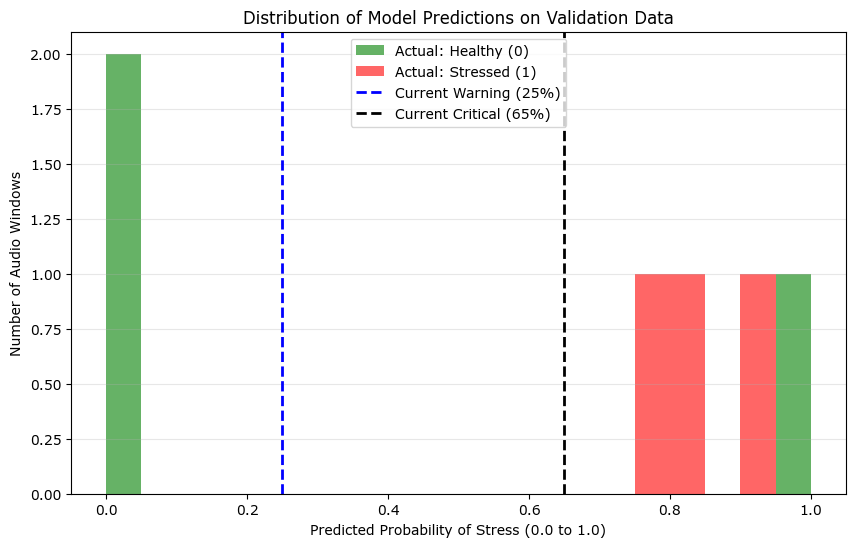

In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION & PATHS ---
MODEL_PATH = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\models\solanum_resnet18_mel.pth")
DATA_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed\solanum")

TARGET_LENGTH = 65000
SAMPLE_RATE = 10000
BATCH_SIZE = 8

# --- 2. DATASET CLASS ---
class PlantPulseMelDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=128,
            n_mels=128
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        mel_db = mel_db.unsqueeze(0)
            
        label = np.array([self.labels[idx]], dtype=np.float32)
        return mel_db, torch.tensor(label)

# --- 3. MODEL ARCHITECTURE ---
class PlantPulseResNet(nn.Module):
    def __init__(self):
        super(PlantPulseResNet, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1)
        )

    def forward(self, x):
        return self.resnet(x)

# --- 4. EXECUTION & PLOTTING LOGIC ---
# Get files
healthy_files = list((DATA_DIR / "healthy").glob("*.npy"))
stressed_files = list((DATA_DIR / "stressed").glob("*.npy"))
all_files = healthy_files + stressed_files
all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)

# Recreate the exact same validation split used during training (using random_state=42)
_, X_temp, _, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
X_val, _, y_val, _ = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

val_dataset = PlantPulseMelDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlantPulseResNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# Run Inference
print(f"Running inference on {len(X_val)} validation samples...")
all_probs = []
all_true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        labels = labels.cpu().numpy().flatten()
        
        all_probs.extend(probs)
        all_true_labels.extend(labels)

# Separate probabilities for the plot
probs_healthy = [p for p, l in zip(all_probs, all_true_labels) if l == 0.0]
probs_stressed = [p for p, l in zip(all_probs, all_true_labels) if l == 1.0]

# --- 5. DRAW THE PLOT ---
plt.figure(figsize=(10, 6))

plt.hist(probs_healthy, bins=20, range=(0, 1), alpha=0.6, color='green', label='Actual: Healthy (0)')
plt.hist(probs_stressed, bins=20, range=(0, 1), alpha=0.6, color='red', label='Actual: Stressed (1)')

plt.axvline(x=0.25, color='blue', linestyle='--', linewidth=2, label='Current Warning (25%)')
plt.axvline(x=0.65, color='black', linestyle='--', linewidth=2, label='Current Critical (65%)')

plt.title('Distribution of Model Predictions on Validation Data')
plt.xlabel('Predicted Probability of Stress (0.0 to 1.0)')
plt.ylabel('Number of Audio Windows')
plt.legend(loc='upper center')
plt.grid(axis='y', alpha=0.3)

plt.show()

# RAW 1

In [9]:
from scipy.io import wavfile
import os

folder = r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw1\plant_sounds"

for f in os.listdir(folder):
    if f.endswith(".wav"):
        sr, data = wavfile.read(os.path.join(folder, f))
        print("Sample rate:", sr)
        print("Shape:", data.shape)
        print("Dtype:", data.dtype)
        break

Sample rate: 22050
Shape: (44100,)
Dtype: int16


In [2]:
import pandas as pd

df = pd.read_csv(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\raw1\plant_stress_sound_dataset.csv")

print(df["Stress_Type"].value_counts())

Stress_Type
Mechanical Damage      211
Pest Infestation       209
Nutrient Deficiency    199
Drought                194
Heat Stress            187
Name: count, dtype: int64


In [3]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
# Pointing exactly to the 5 folders you just created
NPY_FOLDERS_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed1\npy_folders")
BATCH_SIZE = 32         
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 0.0003 
# Full 2 seconds of audio at 44.1kHz
TARGET_LENGTH = 88200   
SAMPLE_RATE = 44100

# --- 1. DATASET & MEL-SPECTROGRAM + SPECAUGMENT ---
class PlantPulseMelDataset(Dataset):
    def __init__(self, file_paths, labels, transform=False):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
        # High-Res MelSpectrogram (Adjusted hop_length for 44.1kHz)
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=512, 
            n_mels=128
        )
        self.amplitude_to_db = T.AmplitudeToDB()
        
        # SpecAugment for robust 2D training
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=15)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load the raw math array from the .npy file
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        # Double check length just in case
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        
        # Convert to Mel-Spectrogram Image
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        
        # Add channel dimension -> Shape: (1, n_mels, time_frames)
        mel_db = mel_db.unsqueeze(0)
        
        if self.transform:
            mel_db = self.freq_mask(mel_db)
            mel_db = self.time_mask(mel_db)
            
        # VERY IMPORTANT: 5-class problems require torch.long integers
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel_db, label

# --- 2. ARCHITECTURE: RESNET18 (TRANSFER LEARNING) ---
class PlantPulseResNet(nn.Module):
    def __init__(self, num_classes=5):
        super(PlantPulseResNet, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Adapt first layer for 1-channel grayscale Mel-spectrograms
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, num_classes) # Now outputs 5 classes instead of 1
        )

    def forward(self, x):
        return self.resnet(x)

# --- 3. TRAINING PIPELINE ---
def main():
    print("Initializing 5-Class Solanum-Style ResNet Pipeline...\n")
    
    if not NPY_FOLDERS_DIR.exists():
        print(f"Error: Directories not found at {NPY_FOLDERS_DIR}.")
        return
        
    # Dynamically find the 5 folders
    folder_names = sorted([d.name for d in NPY_FOLDERS_DIR.iterdir() if d.is_dir()])
    print(f"Found {len(folder_names)} classes: {folder_names}")
    
    all_files = []
    all_labels = []
    
    # Assign labels 0, 1, 2, 3, 4 automatically based on the folder
    for label_idx, folder_name in enumerate(folder_names):
        folder_path = NPY_FOLDERS_DIR / folder_name
        files = list(folder_path.glob("*.npy"))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))
        print(f"  - Loaded {len(files)} files for '{folder_name}' (Label: {label_idx})")
        
    print(f"\nTotal Data: {len(all_files)} samples")

    # Stratified Split (80% Train, 20% Val)
    X_train, X_val, y_train, y_val = train_test_split(all_files, all_labels, test_size=0.2, stratify=all_labels, random_state=42)
    
    print(f"Split: Train={len(X_train)} | Val={len(X_val)}")

    train_dataset = PlantPulseMelDataset(X_train, y_train, transform=True)
    val_dataset = PlantPulseMelDataset(X_val, y_val, transform=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nTraining on: {device.type.upper()}\n")
    
    model = PlantPulseResNet(num_classes=len(folder_names)).to(device)
    
    # Updated to Multi-Class Loss
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            
            # Updated Accuracy Calc for 5 Classes
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        scheduler.step()

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                
                # Updated Accuracy Calc for 5 Classes
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # Save model in the root models folder
    MODELS_DIR = NPY_FOLDERS_DIR.parent.parent.parent / "models"
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    save_path = MODELS_DIR / "plantpulse_5class_resnet.pth"
    
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), save_path)
    print(f"\nBest model saved to: {save_path}")

if __name__ == "__main__":
    main()

Initializing 5-Class Solanum-Style ResNet Pipeline...

Found 5 classes: ['drought', 'heat_stress', 'mechanical_damage', 'nutrient_deficiency', 'pest_infestation']
  - Loaded 194 files for 'drought' (Label: 0)
  - Loaded 187 files for 'heat_stress' (Label: 1)
  - Loaded 211 files for 'mechanical_damage' (Label: 2)
  - Loaded 199 files for 'nutrient_deficiency' (Label: 3)
  - Loaded 209 files for 'pest_infestation' (Label: 4)

Total Data: 1000 samples
Split: Train=800 | Val=200

Training on: CUDA



c:\miniconda3\envs\yolo_env\lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Epoch 001/100 | LR: 0.000300 | Train Loss: 1.8282 Acc: 0.2125 | Val Loss: 1.8125 Acc: 0.1850
Epoch 002/100 | LR: 0.000300 | Train Loss: 1.7932 Acc: 0.1913 | Val Loss: 1.6531 Acc: 0.2000
Epoch 003/100 | LR: 0.000299 | Train Loss: 1.7686 Acc: 0.1688 | Val Loss: 1.6548 Acc: 0.1900
Epoch 004/100 | LR: 0.000299 | Train Loss: 1.7160 Acc: 0.2125 | Val Loss: 1.6583 Acc: 0.2100
Epoch 005/100 | LR: 0.000298 | Train Loss: 1.6993 Acc: 0.2325 | Val Loss: 1.6225 Acc: 0.2100
Epoch 006/100 | LR: 0.000297 | Train Loss: 1.7127 Acc: 0.2000 | Val Loss: 1.6359 Acc: 0.2000
Epoch 007/100 | LR: 0.000296 | Train Loss: 1.6616 Acc: 0.2200 | Val Loss: 1.6279 Acc: 0.2050
Epoch 008/100 | LR: 0.000295 | Train Loss: 1.6695 Acc: 0.2338 | Val Loss: 1.6310 Acc: 0.1850
Epoch 009/100 | LR: 0.000294 | Train Loss: 1.6705 Acc: 0.2013 | Val Loss: 1.6187 Acc: 0.1900
Epoch 010/100 | LR: 0.000293 | Train Loss: 1.6786 Acc: 0.1825 | Val Loss: 1.6384 Acc: 0.2050
Epoch 011/100 | LR: 0.000291 | Train Loss: 1.6625 Acc: 0.2362 | Val Lo

# RAW 3

In [16]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED2_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed2")

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 0.0002  # Balanced learning rate
SAMPLE_RATE = 500000 
TARGET_LENGTH = 1000 

# --- 1. DATASET & MIXUP AUGMENTATION ---
class UltrasonicMixupDataset(Dataset):
    def __init__(self, file_paths, labels, transform=False):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=256,
            hop_length=32,
            n_mels=64
        )
        self.amplitude_to_db = T.AmplitudeToDB()
        
        self.freq_mask = T.FrequencyMasking(freq_mask_param=4)
        self.time_mask = T.TimeMasking(time_mask_param=4)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        mel_db = mel_db.unsqueeze(0)
        
        if self.transform:
            mel_db = self.freq_mask(mel_db)
            mel_db = self.time_mask(mel_db)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel_db, label

# --- 2. STABLE RESNET18 ARCHITECTURE ---
class SolanumUltrasonicResNet(nn.Module):
    def __init__(self, num_classes=3):
        super(SolanumUltrasonicResNet, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# --- 3. TRAINING PIPELINE ---
def main():
    print("Initializing Stable High-Performance Ultrasonic Pipeline...\n")
    
    if not PROCESSED2_DIR.exists():
        print(f"Error: {PROCESSED2_DIR} does not exist.")
        return
        
    folder_names = sorted([d.name for d in PROCESSED2_DIR.iterdir() if d.is_dir()])
    print(f"Detected Classes ({len(folder_names)}): {folder_names}")
    
    all_files, all_labels = [], []
    for label_idx, folder_name in enumerate(folder_names):
        files = list((PROCESSED2_DIR / folder_name).glob("*.npy"))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))
        print(f"  - Loaded {len(files)} files for '{folder_name}' (Label {label_idx})")
        
    print(f"\nTotal Dataset: {len(all_files)} samples")

    X_train, X_val, y_train, y_val = train_test_split(
        all_files, all_labels, test_size=0.2, stratify=all_labels, random_state=42
    )

    train_dataset = UltrasonicMixupDataset(X_train, y_train, transform=True)
    val_dataset = UltrasonicMixupDataset(X_val, y_val, transform=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nTraining on Device: {device.type.upper()}\n")
    
    train_label_counts = [y_train.count(i) for i in range(len(folder_names))]
    total_train = len(y_train)
    weights = [total_train / (len(folder_names) * count) for count in train_label_counts]
    class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
    
    print(f"Calculated Class Weights: {weights}")

    model = SolanumUltrasonicResNet(num_classes=len(folder_names)).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, verbose=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        scheduler.step(val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    MODELS_DIR = PROCESSED2_DIR.parent.parent / "models"
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    save_path = MODELS_DIR / "solanum_ultrasonic_resnet.pth"
    
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), save_path)
    print(f"\nBest model saved to: {save_path} (Best Val Loss: {best_val_loss:.4f})")

if __name__ == "__main__":
    main()

Initializing Stable High-Performance Ultrasonic Pipeline...

Detected Classes (3): ['empty_pot', 'tomato_cut', 'tomato_dry']
  - Loaded 48 files for 'empty_pot' (Label 0)
  - Loaded 660 files for 'tomato_cut' (Label 1)
  - Loaded 1622 files for 'tomato_dry' (Label 2)

Total Dataset: 2330 samples

Training on Device: CUDA

Calculated Class Weights: [16.350877192982455, 1.1767676767676767, 0.4786851566512583]


c:\miniconda3\envs\yolo_env\lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(


Epoch 001/100 | Train Loss: 1.2123 Acc: 0.4480 | Val Loss: 0.8497 Acc: 0.5536
Epoch 005/100 | Train Loss: 0.7184 Acc: 0.5998 | Val Loss: 0.4906 Acc: 0.6674
Epoch 010/100 | Train Loss: 0.5730 Acc: 0.6824 | Val Loss: 0.4264 Acc: 0.7554
Epoch 015/100 | Train Loss: 0.5565 Acc: 0.7012 | Val Loss: 0.4332 Acc: 0.7382
Epoch 00016: reducing learning rate of group 0 to 1.0000e-04.
Epoch 020/100 | Train Loss: 0.4410 Acc: 0.7350 | Val Loss: 0.4275 Acc: 0.7082
Epoch 025/100 | Train Loss: 0.4282 Acc: 0.7430 | Val Loss: 0.4382 Acc: 0.6824
Epoch 00027: reducing learning rate of group 0 to 5.0000e-05.
Epoch 030/100 | Train Loss: 0.3860 Acc: 0.7516 | Val Loss: 0.4056 Acc: 0.8047
Epoch 035/100 | Train Loss: 0.3740 Acc: 0.7833 | Val Loss: 0.3916 Acc: 0.7747
Epoch 00037: reducing learning rate of group 0 to 2.5000e-05.
Epoch 040/100 | Train Loss: 0.3545 Acc: 0.7876 | Val Loss: 0.3974 Acc: 0.7790
Epoch 00042: reducing learning rate of group 0 to 1.2500e-05.
Epoch 045/100 | Train Loss: 0.3465 Acc: 0.7747 | V

In [17]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED2_DIR = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed2")
SAMPLE_RATE = 500000  # 500 kHz Ultrasonic
TARGET_LENGTH = 1000  # 1000 samples per pop
MODEL_PATH = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\models\solanum_ultrasonic_resnet.pth")
BATCH_SIZE = 32

# --- DATASET (Matching 3-Class Ultrasonic Training) ---
class UltrasonicTestDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=256,
            hop_length=32,
            n_mels=64
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        mel_db = mel_db.unsqueeze(0)
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel_db, label

# --- 3-CLASS MODEL ARCHITECTURE ---
class SolanumUltrasonicResNet(nn.Module):
    def __init__(self, num_classes=3):
        super(SolanumUltrasonicResNet, self).__init__()
        self.resnet = models.resnet18(weights=None)
        
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

def main():
    print("Loading 3-class ultrasonic test data...")
    
    if not PROCESSED2_DIR.exists():
        print(f"Error: {PROCESSED2_DIR} not found.")
        return
        
    folder_names = sorted([d.name for d in PROCESSED2_DIR.iterdir() if d.is_dir()])
    
    all_files = []
    all_labels = []
    
    for label_idx, folder_name in enumerate(folder_names):
        folder_path = PROCESSED2_DIR / folder_name
        files = list(folder_path.glob("*.npy"))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))

    # Recreate the exact same 80/20 split used during training
    _, X_val, _, y_val = train_test_split(
        all_files, all_labels, test_size=0.2, stratify=all_labels, random_state=42
    )
    
    print(f"Validation/Test Set Size: {len(X_val)} samples")

    test_dataset = UltrasonicTestDataset(X_val, y_val)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluating on: {device.type.upper()}")

    model = SolanumUltrasonicResNet(num_classes=len(folder_names)).to(device)
    if not MODEL_PATH.exists():
        print(f"Error: Model weights not found at {MODEL_PATH}.")
        return
        
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    all_preds = []
    all_targets = []

    print("Running inference on test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(labels.numpy().flatten())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    test_acc = np.mean(all_preds == all_targets)
    
    print("\n================ FINAL ULTRASONIC TEST RESULTS ================")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=folder_names))
    print("================================================================")

if __name__ == "__main__":
    main()

Loading 3-class ultrasonic test data...
Validation/Test Set Size: 466 samples
Evaluating on: CUDA


c:\miniconda3\envs\yolo_env\lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(


Running inference on test set...

================ FINAL ULTRASONIC TEST RESULTS ================
Test Accuracy: 79.18%

Confusion Matrix:
[[ 10   0   0]
 [  0  99  33]
 [  0  64 260]]

Classification Report:
              precision    recall  f1-score   support

   empty_pot       1.00      1.00      1.00        10
  tomato_cut       0.61      0.75      0.67       132
  tomato_dry       0.89      0.80      0.84       324

    accuracy                           0.79       466
   macro avg       0.83      0.85      0.84       466
weighted avg       0.81      0.79      0.80       466

